# FahMai OCR Competition: Dataset EDA and Preprocessing Plan

This notebook profiles the standalone OCR competition bundle before running Typhoon-OCR.
It deliberately treats the competition folder as the source of truth. The larger enterprise
bundle may be used for structural screening only after checking the competition rules.

## Key distinction

- Submission rows are artifact-level predictions.
- Render files are page-level inputs.
- A single bank-statement artifact contains one header image and multiple transaction images.
- Signatures, stamps, QR codes, and barcodes are visual noise unless they are explicitly listed
  in `visible_fields`.

The notebook exports reusable inventory CSV files into `eda_outputs/`. It does not run OCR and
does not join provenance row IDs back to enterprise tables.

## 1. Setup

The root finder works when the notebook is launched from the competition root or from
`notebooks/`.

In [1]:
from pathlib import Path
from collections import Counter
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "super-ai-engineer-season-6-fah-mai-the-finale-ocr"]
DATA_ROOT = next(
    path.resolve()
    for path in candidates
    if (path / "sample_submission_OCR.csv").is_file()
    and (path / "fahmai_renders_with_json").is_dir()
)
BUNDLE_ROOT = DATA_ROOT / "fahmai_renders_with_json"
SIDECAR_ROOT = BUNDLE_ROOT / "per_artifact"
RENDER_ROOT = BUNDLE_ROOT / "renders"
OUTPUT_DIR = DATA_ROOT / "eda_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"DATA_ROOT   = {DATA_ROOT}")
print(f"BUNDLE_ROOT = {BUNDLE_ROOT}")
print(f"OUTPUT_DIR  = {OUTPUT_DIR}")

DATA_ROOT   = C:\Users\CPE KMUTT\Documents\GitHub\superai_engineer_ss6\Level 2\Hackathon 8_FahMai The Finale\super-ai-engineer-season-6-fah-mai-the-finale-ocr
BUNDLE_ROOT = C:\Users\CPE KMUTT\Documents\GitHub\superai_engineer_ss6\Level 2\Hackathon 8_FahMai The Finale\super-ai-engineer-season-6-fah-mai-the-finale-ocr\fahmai_renders_with_json
OUTPUT_DIR  = C:\Users\CPE KMUTT\Documents\GitHub\superai_engineer_ss6\Level 2\Hackathon 8_FahMai The Finale\super-ai-engineer-season-6-fah-mai-the-finale-ocr\eda_outputs


## 2. Artifact and Page Inventory

There are fewer JSON files than render files by design. Each JSON file is an artifact-level
sidecar. Its `pages[]` array references every input page belonging to that artifact.

In [2]:
sidecar_rows = []
page_rows = []

for sidecar_path in sorted(SIDECAR_ROOT.rglob("*.json")):
    payload = json.loads(sidecar_path.read_text(encoding="utf-8"))
    artifact_type = sidecar_path.parent.name
    sidecar_rows.append(
        {
            "artifact_id": payload["artifact_id"],
            "artifact_type": artifact_type,
            "renderer_template_id": payload.get("renderer_template_id"),
            "template_version": payload.get("template_version"),
            "page_count": len(payload["pages"]),
            "sidecar_path": sidecar_path.relative_to(BUNDLE_ROOT).as_posix(),
        }
    )
    for stored_page_index, page in enumerate(payload["pages"]):
        output_path = page["output_path"].replace("\\", "/").lstrip("./")
        page_rows.append(
            {
                "artifact_id": payload["artifact_id"],
                "artifact_type": artifact_type,
                "renderer_template_id": payload.get("renderer_template_id"),
                "template_version": payload.get("template_version"),
                "stored_page_index": stored_page_index,
                "output_path": output_path,
                "extension": Path(output_path).suffix.lower(),
                "page_kind": page.get("page_kind"),
                "source_fact_table": page.get("source_fact_table"),
                "source_row_id_count": len(page.get("source_row_ids", [])),
                "visible_field_count": len(page.get("visible_fields", [])),
                "visible_fields": tuple(page.get("visible_fields", [])),
            }
        )

sidecars = pd.DataFrame(sidecar_rows)
pages = pd.DataFrame(page_rows)

artifact_type_summary = (
    sidecars.groupby("artifact_type", as_index=False)
    .agg(
        artifacts=("artifact_id", "size"),
        pages=("page_count", "sum"),
        min_pages=("page_count", "min"),
        mean_pages=("page_count", "mean"),
        max_pages=("page_count", "max"),
    )
    .sort_values("artifacts", ascending=False)
)

print(f"Artifact JSON files: {len(sidecars):,}")
print(f"Referenced pages:     {len(pages):,}")
display(artifact_type_summary.round({"mean_pages": 2}))

Artifact JSON files: 3,750
Referenced pages:     6,128


,artifact_type,artifacts,pages,min_pages,mean_pages,max_pages
6,warranty_form,1963,1963,1,1.00,1
5,vendor_invoice,792,792,1,1.00,1
2,receipt,563,563,1,1.00,1
0,bank_statement,336,2714,2,8.08,39
3,t2_doc,81,81,1,1.00,1
4,t3_doc,11,11,1,1.00,1
1,e7_banner,4,4,1,1.00,1


In [3]:
template_summary = (
    pages.groupby(["artifact_type", "renderer_template_id"], as_index=False)
    .agg(
        artifacts=("artifact_id", "nunique"),
        pages=("output_path", "size"),
        extensions=("extension", lambda values: ", ".join(sorted(set(values)))),
    )
    .sort_values(["artifact_type", "renderer_template_id"])
)
display(template_summary)

,artifact_type,renderer_template_id,artifacts,pages,extensions
0,bank_statement,bank_statement_bbl,96,670,.png
1,bank_statement,bank_statement_kbank,120,1201,.png
2,bank_statement,bank_statement_scb,120,843,.png
3,e7_banner,e7_banner_modern_flat,4,4,.png
4,receipt,receipt_thermal,563,563,.png
5,t2_doc,t2_doc_audit_report,2,2,.pdf
6,t2_doc,t2_doc_email_discrete,12,12,.pdf
7,t2_doc,t2_doc_memo_announcement,28,28,.pdf
8,t2_doc,t2_doc_policy_doc,12,12,.pdf
9,t2_doc,t2_doc_training_material,5,5,.pdf


## 3. Mapping Integrity

A robust OCR runner should fail early when a render is orphaned, a JSON path is missing, or a
submission artifact has no sidecar. This cell checks all three conditions.

In [4]:
actual_renders = {
    path.relative_to(BUNDLE_ROOT).as_posix()
    for path in RENDER_ROOT.rglob("*")
    if path.is_file()
}
referenced_renders = set(pages["output_path"])
duplicate_page_refs = int(pages["output_path"].duplicated().sum())

sample_submission = pd.read_csv(DATA_ROOT / "sample_submission_OCR.csv")
submission_ids = set(sample_submission["artifact_id"])
sidecar_ids = set(sidecars["artifact_id"])

integrity = pd.DataFrame(
    [
        {"check": "actual render files", "count": len(actual_renders)},
        {"check": "page references in sidecars", "count": len(pages)},
        {"check": "unique page references", "count": len(referenced_renders)},
        {"check": "orphan render files", "count": len(actual_renders - referenced_renders)},
        {"check": "missing referenced renders", "count": len(referenced_renders - actual_renders)},
        {"check": "duplicate referenced paths", "count": duplicate_page_refs},
        {"check": "sample submission rows", "count": len(sample_submission)},
        {"check": "sidecar artifacts", "count": len(sidecars)},
        {"check": "submission IDs missing sidecars", "count": len(submission_ids - sidecar_ids)},
        {"check": "sidecar IDs missing submission rows", "count": len(sidecar_ids - submission_ids)},
    ]
)
display(integrity)

assert not (actual_renders - referenced_renders)
assert not (referenced_renders - actual_renders)
assert duplicate_page_refs == 0
assert submission_ids == sidecar_ids

,check,count
0,actual render files,6128
1,page references in sidecars,6128
2,unique page references,6128
3,orphan render files,0
4,missing referenced renders,0
5,duplicate referenced paths,0
6,sample submission rows,3750
7,sidecar artifacts,3750
8,submission IDs missing sidecars,0
9,sidecar IDs missing submission rows,0


## 4. Image and PDF Formats

PNG images should be passed at their native resolution for the first Typhoon-OCR baseline.
Avoid one global resize rule: receipts are narrow and variable-height, while KBank statements
are much larger than BBL/SCB statements.

In [5]:
image_rows = []
for output_path in pages.loc[pages["extension"].eq(".png"), "output_path"]:
    absolute_path = BUNDLE_ROOT / output_path
    with Image.open(absolute_path) as image:
        image_rows.append(
            {
                "output_path": output_path,
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
                "format": image.format,
            }
        )

image_metadata = pages.merge(pd.DataFrame(image_rows), on="output_path", how="left")
png_metadata = image_metadata[image_metadata["extension"].eq(".png")].copy()

image_size_summary = (
    png_metadata.groupby(
        ["artifact_type", "renderer_template_id", "width", "height", "mode"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "pages"})
    .sort_values(["artifact_type", "renderer_template_id", "pages"], ascending=[True, True, False])
)
display(image_size_summary)

,artifact_type,renderer_template_id,width,height,mode,pages
1,bank_statement,bank_statement_bbl,1240.0,1234.0,RGB,574
0,bank_statement,bank_statement_bbl,1240.0,520.0,RGB,96
3,bank_statement,bank_statement_kbank,2968.0,2850.0,RGB,1081
2,bank_statement,bank_statement_kbank,2966.0,839.0,RGB,120
5,bank_statement,bank_statement_scb,1240.0,1234.0,RGB,723
4,bank_statement,bank_statement_scb,1240.0,520.0,RGB,120
6,e7_banner,e7_banner_modern_flat,2304.0,1536.0,RGB,4
7,receipt,receipt_thermal,606.0,1362.0,RGB,413
9,receipt,receipt_thermal,606.0,1416.0,RGB,28
14,receipt,receipt_thermal,606.0,1582.0,RGB,24


In [6]:
try:
    from pypdf import PdfReader

    pdf_rows = []
    for output_path in pages.loc[pages["extension"].eq(".pdf"), "output_path"]:
        reader = PdfReader(str(BUNDLE_ROOT / output_path))
        text = "\n".join(page.extract_text() or "" for page in reader.pages)
        pdf_rows.append(
            {
                "output_path": output_path,
                "pdf_pages": len(reader.pages),
                "encrypted": reader.is_encrypted,
                "text_layer_characters": len(text.strip()),
            }
        )
    pdf_metadata = pages.merge(pd.DataFrame(pdf_rows), on="output_path", how="right")
    display(
        pdf_metadata.groupby(["artifact_type", "renderer_template_id"], as_index=False)
        .agg(
            pdf_files=("output_path", "size"),
            min_pdf_pages=("pdf_pages", "min"),
            max_pdf_pages=("pdf_pages", "max"),
            min_text_chars=("text_layer_characters", "min"),
            max_text_chars=("text_layer_characters", "max"),
        )
    )
except ImportError:
    pdf_metadata = pd.DataFrame()
    print("Install pypdf to profile PDF page counts and text layers.")

,artifact_type,renderer_template_id,pdf_files,min_pdf_pages,max_pdf_pages,min_text_chars,max_text_chars
0,t2_doc,t2_doc_audit_report,2,1,1,893,919
1,t2_doc,t2_doc_email_discrete,12,1,1,439,464
2,t2_doc,t2_doc_memo_announcement,28,1,1,470,546
3,t2_doc,t2_doc_policy_doc,12,1,1,497,578
4,t2_doc,t2_doc_training_material,5,1,1,680,709
5,t2_doc,t2_doc_vendor_contract,22,1,1,731,860


### Preprocessing recommendations

| Template family | First-pass input | Parser focus | Ignore in output |
|---|---|---|---|
| Bank statement header | Native PNG | `L0_*` account fields | logos, addresses, report timestamps |
| Bank transaction page | Native PNG, optionally crop table for retry | transaction rows in visual order | carry-over row, summary, footer |
| Receipt | Native PNG | receipt ID, branch, date, totals, payment | cashier signature, QR, barcode |
| Vendor invoice | Native PNG | seven requested invoice/payment fields | signature, stamp, barcode, non-requested totals |
| Warranty form | Native PNG | six requested claim fields | three signatures, stamps, barcode, masked PII |
| T2 PDF | Direct PDF text baseline, then render at 150-200 DPI for VLM retry | requested metadata fields | approval lines and boilerplate |
| T3 legal PNG | Native PNG | requested party metadata | signatures, stamps, narrative body |
| Banner | Native PNG | requested campaign fields | QR and marketing boilerplate |

Do not mask stamps or signatures before the first pass. A stamp can overlap useful text, especially
in warranty forms. Prefer template-aware parsing first, then apply region masks only for retry cases.

## 5. Requested Field Catalog

`visible_fields` is the safest schema scaffold. It specifies what the parser should return without
filling values from enterprise source tables.

In [7]:
field_catalog = (
    pages[["artifact_type", "renderer_template_id", "source_fact_table", "visible_fields"]]
    .explode("visible_fields")
    .rename(columns={"visible_fields": "field"})
    .drop_duplicates()
    .sort_values(["artifact_type", "renderer_template_id", "field"])
    .reset_index(drop=True)
)
display(field_catalog)

,artifact_type,renderer_template_id,source_fact_table,field
0,bank_statement,bank_statement_bbl,DIM_BANK_ACCOUNT,account_id
1,bank_statement,bank_statement_bbl,FACT_BANK_TRANSACTION,account_id
2,bank_statement,bank_statement_bbl,DIM_BANK_ACCOUNT,account_number
3,bank_statement,bank_statement_bbl,DIM_BANK_ACCOUNT,account_role
4,bank_statement,bank_statement_bbl,FACT_BANK_TRANSACTION,amount_thb
5,bank_statement,bank_statement_bbl,FACT_BANK_TRANSACTION,balance_after_thb
6,bank_statement,bank_statement_bbl,DIM_BANK_ACCOUNT,bank
7,bank_statement,bank_statement_bbl,FACT_BANK_TRANSACTION,business_event_date
8,bank_statement,bank_statement_bbl,DIM_BANK_ACCOUNT,currency
9,bank_statement,bank_statement_bbl,FACT_BANK_TRANSACTION,description


## 6. Estimated Scoring Weight

The competition weights artifacts by requested field count. Bank statements contain many
transaction rows, so they dominate the estimated field-level workload. The estimate below
deduplicates bank transaction IDs because some sidecars repeat the full statement ID list on
every transaction page.

In [8]:
sidecar_payloads = {
    payload["artifact_id"]: payload
    for path in SIDECAR_ROOT.rglob("*.json")
    for payload in [json.loads(path.read_text(encoding="utf-8"))]
}

weight_rows = []
for row in sidecars.itertuples(index=False):
    payload = sidecar_payloads[row.artifact_id]
    if row.artifact_type == "bank_statement":
        transaction_ids = []
        for page in payload["pages"]:
            if page.get("source_fact_table") == "FACT_BANK_TRANSACTION":
                transaction_ids.extend(page.get("source_row_ids", []))
        unique_transaction_ids = list(dict.fromkeys(transaction_ids))
        estimated_fields = 5 + 6 * len(unique_transaction_ids)
    else:
        fields = []
        for page in payload["pages"]:
            fields.extend(page.get("visible_fields", []))
        estimated_fields = len(list(dict.fromkeys(fields)))
    weight_rows.append(
        {
            "artifact_id": row.artifact_id,
            "artifact_type": row.artifact_type,
            "estimated_requested_fields": estimated_fields,
        }
    )

requested_field_weights = pd.DataFrame(weight_rows)
requested_field_weight_summary = (
    requested_field_weights.groupby("artifact_type", as_index=False)
    .agg(
        artifacts=("artifact_id", "size"),
        estimated_requested_fields=("estimated_requested_fields", "sum"),
    )
    .sort_values("estimated_requested_fields", ascending=False)
)
requested_field_weight_summary["estimated_weight_pct"] = (
    requested_field_weight_summary["estimated_requested_fields"]
    / requested_field_weight_summary["estimated_requested_fields"].sum()
    * 100
)
display(requested_field_weight_summary.round({"estimated_weight_pct": 2}))

,artifact_type,artifacts,estimated_requested_fields,estimated_weight_pct
0,bank_statement,336,393672,94.77
6,warranty_form,1963,11778,2.84
5,vendor_invoice,792,5544,1.33
2,receipt,563,3941,0.95
3,t2_doc,81,417,0.10
4,t3_doc,11,46,0.01
1,e7_banner,4,20,0.00


## 7. Bank-Statement Diagnostics

Bank statements need their own assembler:

1. Natural-sort transaction page filenames (`p2` before `p10`).
2. OCR the header separately.
3. OCR transaction rows in visual order.
4. Drop carry-over, totals, and footer rows.
5. Match the remaining rows to the deduplicated BT-ID sequence with a cursor.
6. Reject or retry the page when parsed row count and expected cursor movement disagree.

The released sidecars currently repeat the full BT-ID list across transaction pages for many
statements, despite the README describing page-level lists. The cursor workaround is usable,
but the organizer should confirm the intended mapping contract.

In [9]:
def natural_page_number(output_path: str) -> int:
    if output_path.endswith("_header.png"):
        return 0
    match = re.search(r"_p(\d+)\.png$", output_path)
    return int(match.group(1)) if match else 999999


bank_diagnostic_rows = []
for row in sidecars.loc[sidecars["artifact_type"].eq("bank_statement")].itertuples(index=False):
    payload = sidecar_payloads[row.artifact_id]
    transaction_pages = [
        page for page in payload["pages"]
        if page.get("source_fact_table") == "FACT_BANK_TRANSACTION"
    ]
    row_id_lists = [page.get("source_row_ids", []) for page in transaction_pages]
    all_ids = [row_id for row_ids in row_id_lists for row_id in row_ids]
    stored_paths = [page["output_path"] for page in transaction_pages]
    natural_paths = sorted(stored_paths, key=natural_page_number)
    bank_diagnostic_rows.append(
        {
            "artifact_id": row.artifact_id,
            "renderer_template_id": row.renderer_template_id,
            "transaction_pages": len(transaction_pages),
            "unique_transaction_ids": len(list(dict.fromkeys(all_ids))),
            "repeated_full_id_list_across_pages": len(row_id_lists) > 1
            and all(row_ids == row_id_lists[0] for row_ids in row_id_lists[1:]),
            "stored_page_order_needs_natural_sort": stored_paths != natural_paths,
        }
    )

bank_diagnostics = pd.DataFrame(bank_diagnostic_rows)
display(
    bank_diagnostics.groupby("renderer_template_id", as_index=False)
    .agg(
        artifacts=("artifact_id", "size"),
        min_transaction_pages=("transaction_pages", "min"),
        max_transaction_pages=("transaction_pages", "max"),
        repeated_id_list_artifacts=("repeated_full_id_list_across_pages", "sum"),
        natural_sort_needed_artifacts=("stored_page_order_needs_natural_sort", "sum"),
    )
)

,renderer_template_id,artifacts,min_transaction_pages,max_transaction_pages,repeated_id_list_artifacts,natural_sort_needed_artifacts
0,bank_statement_bbl,96,1,8,72,0
1,bank_statement_kbank,120,2,38,120,24
2,bank_statement_scb,120,1,8,96,0


## 8. Visual Noise: Signatures, Stamps, Barcodes, and QR Codes

Visual inspection of representative files shows:

- Receipts contain cashier signatures, barcodes, and QR codes.
- Vendor invoices contain an authorized signature, company stamp, and barcode.
- Warranty forms contain three signatures, approval/service stamps, masked PII, and a barcode.
- T3 legal documents contain signatures and approval/termination stamps.
- T2 PDF documents may contain approval or signature lines, usually without handwriting.

These elements are not requested fields. They should remain visible during the first OCR pass so
that the document layout stays intact, but the structured parser must discard them. Optional
template-specific masks belong in retry preprocessing, not in the default pipeline.

receipt -> renders/receipt/2024-01/RC-TXN-202401-02004012.png


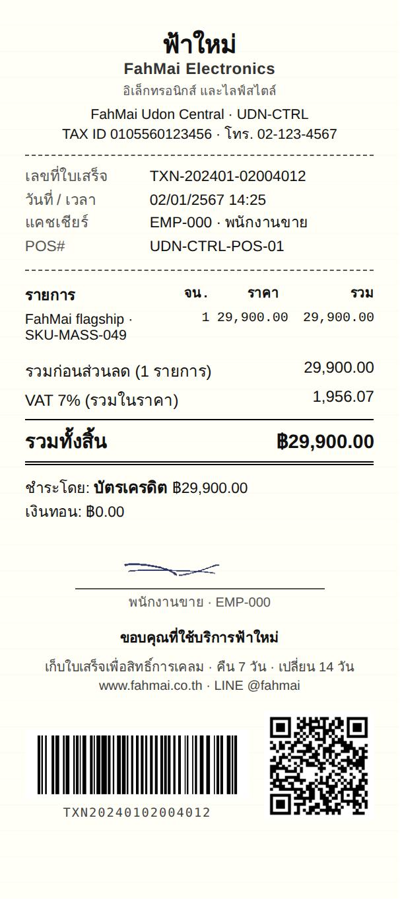

vendor_invoice -> renders/vendor_invoice/2024-12/VI-V-001-INV-2567-1014725.png


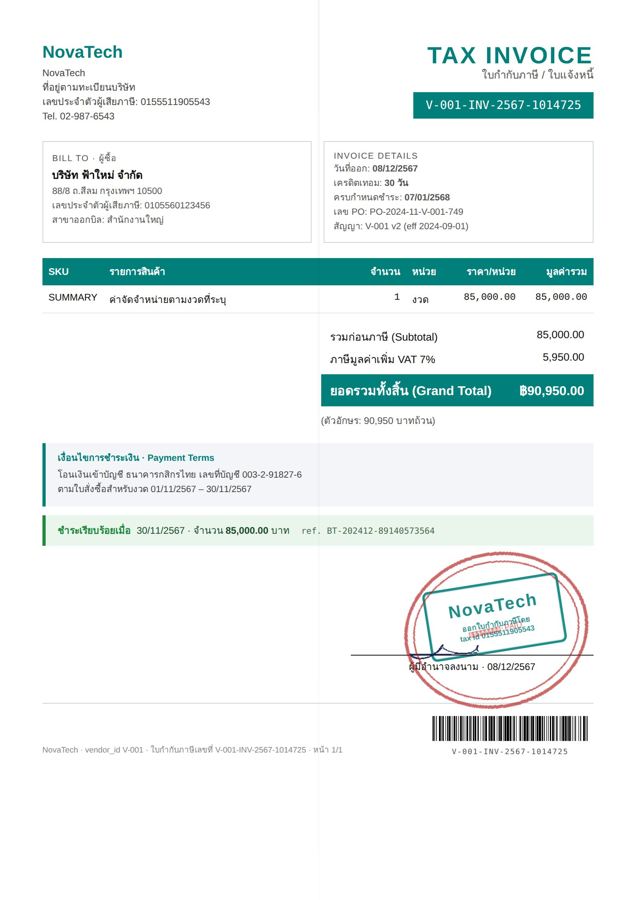

warranty_form -> renders/warranty_form/2024-02/WC-AW-MN-001-202402-12026091.png


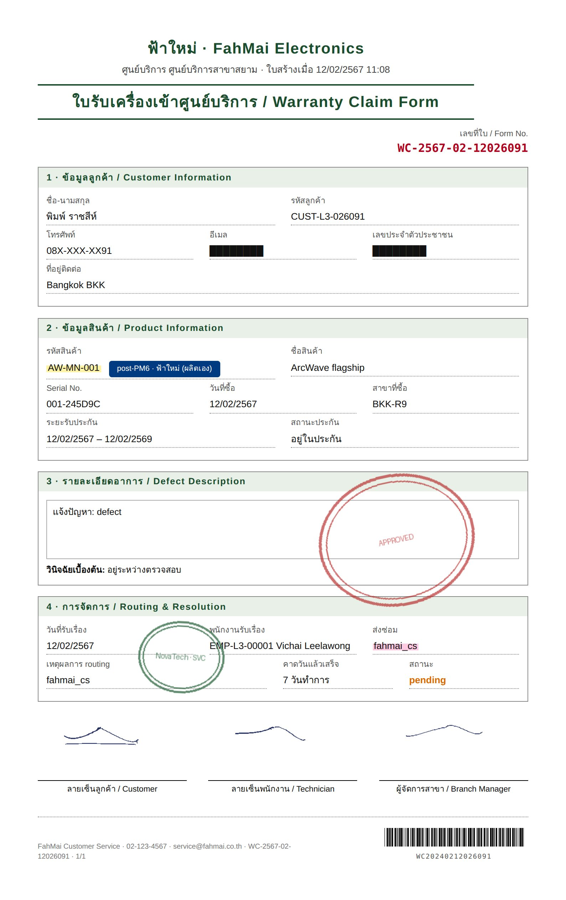

t3_lease -> renders/t3_doc/2024-01/T3-LEASE-BKKCTW-2566-04-01.png


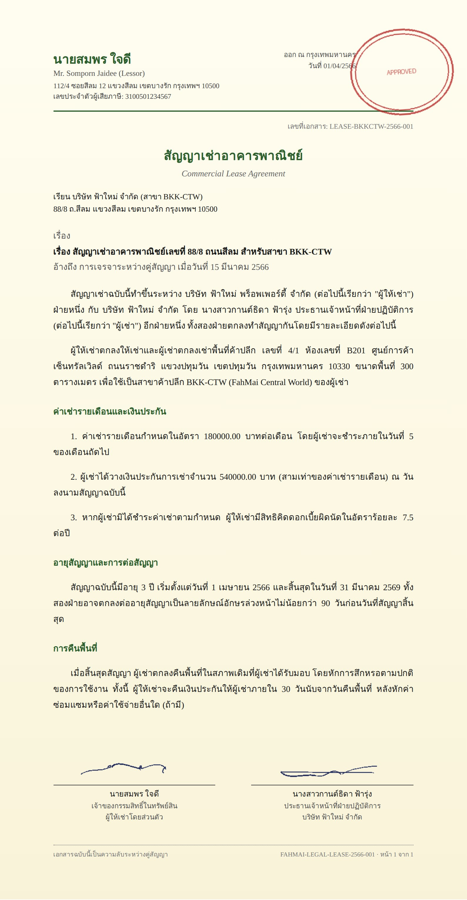

t3_termination -> renders/t3_doc/2025-03/T3-TERM-V-014-2568-03-31.png


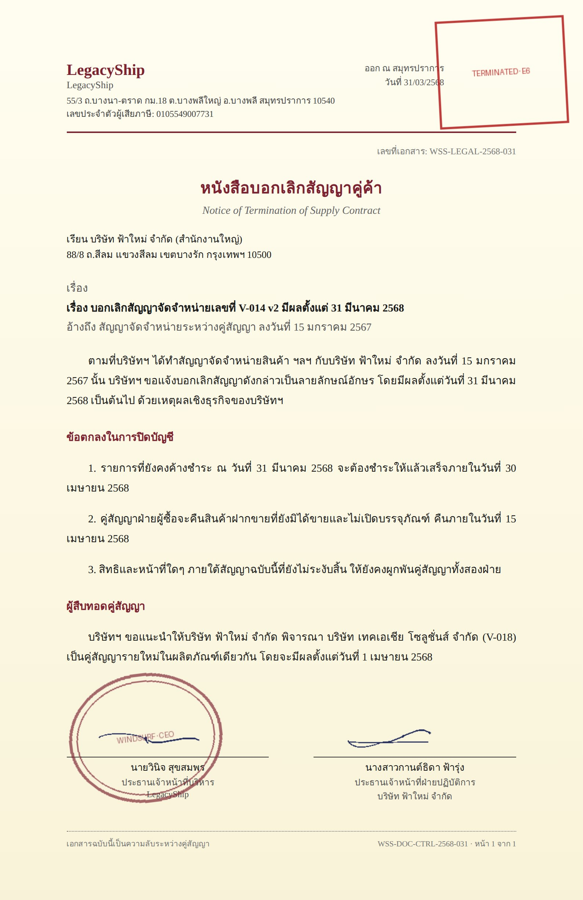

In [10]:
representative_paths = {
    "receipt": "renders/receipt/2024-01/RC-TXN-202401-02004012.png",
    "vendor_invoice": "renders/vendor_invoice/2024-12/VI-V-001-INV-2567-1014725.png",
    "warranty_form": "renders/warranty_form/2024-02/WC-AW-MN-001-202402-12026091.png",
    "t3_lease": "renders/t3_doc/2024-01/T3-LEASE-BKKCTW-2566-04-01.png",
    "t3_termination": "renders/t3_doc/2025-03/T3-TERM-V-014-2568-03-31.png",
}

for label, relative_path in representative_paths.items():
    print(label, "->", relative_path)
    preview = Image.open(BUNDLE_ROOT / relative_path).copy()
    preview.thumbnail((900, 900))
    display(preview)

## 9. Safe Use of the Larger Enterprise Bundle

The larger enterprise dataset is useful for:

- profiling format patterns and enum vocabularies;
- building regex validators for IDs, dates, and currency fields;
- checking OCR failure modes after inference;
- preparing a local development split when the rules explicitly allow it.

Do not use provenance `source_row_ids` to join tables and fill competition predictions unless the
organizer explicitly confirms that this is allowed. The supplied README states that such joins can
make visual-grounding questions trivial. Keep the OCR baseline visually grounded and log any
table-assisted experiment separately.

## 10. Typhoon-OCR Runner Contract

A practical runner should emit one structured record per page before assembling artifacts:

```json
{
  "artifact_id": "BS-...",
  "page_path": "renders/bank_statement/..._transactions_p1.png",
  "template": "bank_statement_bbl",
  "parsed_rows": [],
  "warnings": [],
  "raw_ocr": "..."
}
```

Keep raw OCR for debugging, but build `pred_json` only from requested fields. This prevents footer,
signature, stamp, QR, and barcode text from leaking into the CER comparison.

## 11. Export Reusable EDA Tables

In [11]:
exports = {
    "sidecar_inventory.csv": sidecars,
    "page_inventory.csv": pages,
    "template_summary.csv": template_summary,
    "image_size_summary.csv": image_size_summary,
    "field_catalog.csv": field_catalog,
    "requested_field_weight_summary.csv": requested_field_weight_summary,
    "bank_statement_diagnostics.csv": bank_diagnostics,
    "mapping_integrity.csv": integrity,
}

if "pdf_metadata" in globals() and not pdf_metadata.empty:
    exports["pdf_metadata.csv"] = pdf_metadata

for filename, frame in exports.items():
    path = OUTPUT_DIR / filename
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"wrote {path.relative_to(DATA_ROOT)} ({len(frame):,} rows)")

wrote eda_outputs\sidecar_inventory.csv (3,750 rows)
wrote eda_outputs\page_inventory.csv (6,128 rows)
wrote eda_outputs\template_summary.csv (15 rows)
wrote eda_outputs\image_size_summary.csv (29 rows)
wrote eda_outputs\field_catalog.csv (99 rows)
wrote eda_outputs\requested_field_weight_summary.csv (7 rows)
wrote eda_outputs\bank_statement_diagnostics.csv (336 rows)
wrote eda_outputs\mapping_integrity.csv (10 rows)
wrote eda_outputs\pdf_metadata.csv (81 rows)
